## NMD Models: IRRBB Integration Report

This notebook shows how to intergrete related component into IRRBB Report.

### Data Flow
```
Notebook 01 → market_rate, deposit_rate, balance, cds_spread
Notebook 02 → hazard_rates
Notebook 03 → stable_pct
Notebook 04 → beta_2 (beta - JVD Model), gamma (beta - Beta Regression), alpha (g - Threshold Model)
Notebook 05 → core_balance, runoff_profile, WAL, IRRBB_buckets
Notebook 06 → EVE base, EVE stressed, ΔEVE
Notebook 07 → floor value (K = 0%, K = d0)
Notebook 08 → caterpillar_yield, duration, NII
Notebook 09 → allocation weights, NII Annual, ΔNII Sensitivity
```

### IRRBB Outputs
| Output | Description | Reference |
|---|---|---|
| EVE Sensitivity able | ΔEVE per rate shock scenario | Section IV |
| NII Sensitivity table | ΔNII year 1 and fully rolled | Section IV |
| Repricing gap | Balance per IRRBB time bucket | Annex 2 |
| NMD Model summary | WAL, core %, floor, caterpillar | Section IV Table 2 |

In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import warnings
import pandas as pd
import pickle
import sys; sys.path.insert(0, "..")

from src.economic_theory import simulate_paths, compute_eve
from src.reporting import build_irrbb_report, build_net_repricing_gap, compute_liquidity_ratios
from src.plot_function import plot_irrbb_results

pd.options.display.float_format = "{:.3f}".format
warnings.simplefilter(action = "ignore", category = pd.errors.PerformanceWarning)

In [3]:
# Load Data
df = pd.read_parquet(
    '../data/raw/nmd_data.parquet',
    engine = "pyarrow"
)

# Extract information
market_rate = df["market_rate"]
deposit_rate = df["deposit_rate"]
cds_spread = df["cds_spread"]
balance = df["balance"]

In [4]:
# Import related models
# Import runoff model
with open("../model/runoff_model.pkl", "rb") as file:
    nb05 = pickle.load(file) #Notebook 05

# Import dynamics model
with open("../model/dynamics_model.pkl", "rb") as file:
    params = pickle.load(file)

# Import yield curve
with open("../model/yield_curve.pkl", "rb") as file:
    yc = pickle.load(file)

In [5]:
# Get Upstream Parameters
stable_pct = 0.9636 #Notebook 03 - HP Model
GAMMA = 0.2072 #Notebook 04 - Beta Regression
ALPHA = 0.0008 #Notebook 04 - Threshold Model
BETA_2 = 0.0797 #Notebook 04 - JVD Model

# Core balance
core_balance = float(balance.iloc[-1]) * stable_pct * (1 - GAMMA) #It is beta long-run

# Non-Core balance
non_core_balance = float(balance.iloc[-1]) - core_balance
nb05["non_core_balance"] = non_core_balance #Add to nb05

# IRRBB buckets
irrbb_buckets = {
    "1-3M": 78.400,
    "3-6M": 36.170,
    "6-12M": 144.930,
    "1-2Y": 280.860,
    "2-3Y": 977.040,
    "3-4Y": 688.610,
    "4-5Y": 485.320,
    "5Y+": 1158.670
}
nb05["irrbb_buckets"] = irrbb_buckets

# NMD Floor
floor_zero = 21.280
floor_atm = 43.429
nb07 = {
    "floor_zero": floor_zero,
    "floor_atm": floor_atm
}

# Caterpillar and Wealth Allocation
y5 = 0.0485; cat_dur = 5.0;
cat_nii = 186.74; tranche_size = 770.03
w_cat_ = 0.85; w_float_ = 0.00; w_liq_ = 0.15
best_nii = 172.82; delta_eve = 199.24
asset_repricing = {
    "Overnight": w_liq_ * core_balance,
    "1-3M": 0.0,
    "3-6M": w_float_ * core_balance,
    "6-12M": 0.0,
    "1-2Y": 0.0,
    "2-3Y": 0.0,
    "3-4Y": 0.0,
    "4-5Y": 0.0,
    "5Y+": w_cat_ * core_balance
}
nb08_09 = {
    "cat_yield": y5,
    "cat_duration": cat_dur,
    "cat_nii": cat_nii,
    "tranche_size": tranche_size,
    "w_cat": w_cat_,
    "w_float": w_float_,
    "w_liq": w_liq_,
    "nii_alloc": best_nii,
    "delta_eve_alloc": delta_eve,
    "yield_curve": yc,
    "asset_repricing": asset_repricing
}

In [6]:
# NB06 EVE per Scenario
## Simulation of Base & Stressed
N_PATHS = 1000
N_MONTHS = 60

# Rate shocks for IRRBB Scenarios (BCBS 368)
RATE_SHOCKS = [0.0, 0.01, 0.02, -0.01, -0.02]

sim_kwargs = dict(
    params = params,
    beta_2 = BETA_2,
    gamma = GAMMA,
    alpha = ALPHA,
    n_paths = N_PATHS,
    n_months = N_MONTHS
)

paths_base = simulate_paths(**sim_kwargs, rate_shock = 0.0, seed = 42)
eve_base = compute_eve(paths_base)

shock_result = {}
delta_result = {}

for s in RATE_SHOCKS:
    paths_stressed = simulate_paths(**sim_kwargs, rate_shock = s, seed = 42)
    eve_stressed = compute_eve(paths_stressed)
    delta = eve_stressed["eve"] - eve_base["eve"]
    shock_result[s] = eve_stressed["eve"]
    delta_result[s] = delta

nb06 = {
    "eve_per_shock": shock_result,
    "eve_base": eve_base["eve"],
    "delta_eve": delta_result

}

In [7]:
# Show parameters
# NB03 and NB04
print("=" * 60)
print(f"{"Gamma":<{15}}: {GAMMA:.4f}")
print(f"{"Alpha":<{15}}: {ALPHA:.4f}")
print(f"{"beta_2":<{15}}: {BETA_2:.4f}")

# NB05
print("=" * 60)
print(f"{"Core balance":<{20}}: {nb05['core_balance']:,.2f} MB")
print(f"{"Non-core balance":<{20}}: {nb05['non_core_balance']:,.2f} MB")
print(f"{"WAL":<{20}}: {nb05['wal_years']:.2f} years")
print(f"{"Seed rate":<{20}}: {nb05['seed_rate']:.2%}")

# NB06
print("=" * 60)
print(f"Scenarios: {[f'{s*10000:.0f}bps' for s in RATE_SHOCKS]}")
print("EVE per Scenario")
for shock, eve in nb06["eve_per_shock"].items():
    label = f"+{int(shock*10000)}bps" if shock>0 else (f"{int(shock*10000)}bps" if shock<0 else "Base")
    delta = nb06["delta_eve"].get(shock,0)
    print(f"    {label:>10}: EVE = {eve:,.2f} MB    ΔEVE = {delta:+,.2f} MB")

# NB07
print("=" * 60)
print(f"{"Floor (K = 0%)":<{20}}: {nb07['floor_zero']:,.2f} MB")
print(f"{"Floor (K = d0)":<{20}}: {nb07['floor_atm']:,.2f} MB")

# NB08 and NB09
print("=" * 60)
print(f"{"Caterpillar yield":<{25}}: {nb08_09['cat_yield']:.2%}")
print(f"{"Caterpillar duration":<{25}}: {nb08_09['cat_duration']:.2f}Y")
print(f"{"NII Full caterpillar":<{25}}: {nb08_09['cat_nii']:,.2f} MB")
print(f"{"Allocation":<{25}}: cat = {nb08_09['w_cat']:.2%} float = {nb08_09['w_float']:.2%} liq = {nb08_09['w_liq']:.2%}")
print(f"{"NII (Allocation)":<{25}}: {nb08_09['nii_alloc']:,.2f} MB")
print("=" * 60)

Gamma          : 0.2072
Alpha          : 0.0008
beta_2         : 0.0797
Core balance        : 3,850.14 MB
Non-core balance    : 1,189.65 MB
WAL                 : 2.84 years
Seed rate           : 2.87%
Scenarios: ['0bps', '100bps', '200bps', '-100bps', '-200bps']
EVE per Scenario
          Base: EVE = 9,502.46 MB    ΔEVE = +0.00 MB
       +100bps: EVE = 8,866.75 MB    ΔEVE = -635.71 MB
       +200bps: EVE = 8,288.11 MB    ΔEVE = -1,214.36 MB
       -100bps: EVE = 10,225.35 MB    ΔEVE = +722.88 MB
       -200bps: EVE = 11,111.38 MB    ΔEVE = +1,608.91 MB
Floor (K = 0%)      : 21.28 MB
Floor (K = d0)      : 43.43 MB
Caterpillar yield        : 4.85%
Caterpillar duration     : 5.00Y
NII Full caterpillar     : 186.74 MB
Allocation               : cat = 85.00% float = 0.00% liq = 15.00%
NII (Allocation)         : 172.82 MB


In [8]:
# Build IRRBB Report
report = build_irrbb_report(
    nb05 = nb05,
    nb06 = nb06,
    nb07 = nb07,
    nb08_09 = nb08_09,
    rate_shocks = RATE_SHOCKS,
    stable_pct = stable_pct,
    beta_2 = BETA_2
)

In [9]:
# NMD Model Summary
print("NMD Model Summary")
report["nmd_summary"]

NMD Model Summary


,Value
Total balance (MB),5039.800
Stable % (NB03),96.36%
Beta / Pass-through (NB04),0.0797
Core balance (MB),3850.100
Non-core balance (MB),1189.600
WAL — liability (years),2.845
Base EVE (MB),9502.500
ΔEVE +200bps (MB),-1214.400
Floor value K=0% (MB),21.280
Floor value K=d0 (MB),43.430


In [10]:
# EVE Sensitivity Table
print("EVE Sensitivity — IRRBB Table")
report["eve_table"][["EVE (MB)","ΔEVE (MB)","ΔEVE (%)"]]

EVE Sensitivity — IRRBB Table


,EVE (MB),ΔEVE (MB),ΔEVE (%)
scenario,,,
Base,9502.500,0.000,—
+100bps,8866.800,-635.700,-6.69%
+200bps,8288.100,-1214.400,-12.78%
-100bps,10225.300,722.900,7.61%
-200bps,11111.400,1608.900,16.93%


In [11]:
# NII Sensitivity Table
print("NII Sensitivity — IRRBB Table")
report["nii_table"]

NII Sensitivity — IRRBB Table


,NII base (MB),ΔNII year 1 (MB),ΔNII fully rolled (MB),% repricing/year
scenario,,,,
+100bps,172.800,6.550,32.730,20.00%
+200bps,172.800,13.090,65.450,20.00%
-100bps,172.800,-6.550,-32.730,20.00%
-200bps,172.800,-13.090,-65.450,20.00%


In [12]:
# Repricing Gap
print("Repricing Gap — IRRBB Buckets")
print(f"Total balance: {nb05['core_balance'] + nb05['non_core_balance']:,.2f} MB")
report["repricing_gap"]

Repricing Gap — IRRBB Buckets
Total balance: 5,039.79 MB


,balance_mb,pct_of_total,description
bucket,,,
Overnight (Non-core),1189.600,23.61%,Reprice immediately
1-3M,78.400,1.56%,Core — behavioral maturity
3-6M,36.200,0.72%,Core — behavioral maturity
6-12M,144.900,2.88%,Core — behavioral maturity
1-2Y,280.900,5.57%,Core — behavioral maturity
2-3Y,977.000,19.39%,Core — behavioral maturity
3-4Y,688.600,13.66%,Core — behavioral maturity
4-5Y,485.300,9.63%,Core — behavioral maturity
5Y+,1158.700,22.99%,Core — behavioral maturity


In [13]:
# Net Repricing Gap
net_gap_table = build_net_repricing_gap(
    liability_buckets = nb05["irrbb_buckets"],
    asset_repricing = nb08_09["asset_repricing"]
)

print("Net Repricing Gap (Asset - Liability)")
print(f"Positive = Asset heavy (benefits from rate rise)")
print(f"Negative = Liability heavy (benefits from rate fall)")
print()
net_gap_table

Net Repricing Gap (Asset - Liability)
Positive = Asset heavy (benefits from rate rise)
Negative = Liability heavy (benefits from rate fall)



,asset_mb,liability_mb,net_gap_mb,cumulative_mb,position
bucket,,,,,
1-3M,0.000,78.400,-78.400,-78.400,Liability heavy
3-6M,0.000,36.200,-36.200,-114.600,Liability heavy
6-12M,0.000,144.900,-144.900,-259.500,Liability heavy
1-2Y,0.000,280.900,-280.900,-540.400,Liability heavy
2-3Y,0.000,977.000,-977.000,-1517.400,Liability heavy
3-4Y,0.000,688.600,-688.600,-2206.000,Liability heavy
4-5Y,0.000,485.300,-485.300,-2691.300,Liability heavy
5Y+,3272.500,1158.700,2113.800,-577.500,Asset heavy


In [14]:
# LCR / NSFR
liquidity_ratios = compute_liquidity_ratios(
    core_balance = nb05["core_balance"],
    non_core_balance = nb05["non_core_balance"],
    nb08_09 = nb08_09
)

lcr = liquidity_ratios["lcr"]
nsfr = liquidity_ratios["nsfr"]

print(f"LCR Detail:")
print(f"  HQLA                : {lcr['hqla']:>8,.2f} MB")
print(f"  Outflow stable      : {lcr['outflow_stable']:>8,.2f} MB (5% x stable core)")
print(f"  Outflow unstable    : {lcr['outflow_unstable']:>7,.2f} MB (10% x unstable core)")
print(f"  Outflow non-core    : {lcr['outflow_noncash']:>8,.2f} MB (25% x non-core)")
print(f"  Total outflow       : {lcr['total_outflow']:>8,.2f} MB")
print(f"  LCR                 : {lcr['lcr_pct']:>8.2f}% {'✓ PASS' if lcr['lcr_pct']>=100 else '✗ FAIL'}")
print(f"  Dynamic MIN_LIQ     : {lcr['min_liq_dynamic']:>8.2%} (current static: 15%)")
print()
print(f"NSFR Detail:")
print(f"  ASF stable NMD      : {nsfr['asf_stable']:>10,.2f} MB (95% x stable core)")
print(f"  ASF unstable NMD    : {nsfr['asf_unstable']:>8,.2f} MB (90% x unstable core)")
print(f"  ASF non-core        : {nsfr['asf_noncash']:>8,.2f} MB (50% x non-core)")
print(f"  ASF total           : {nsfr['asf_total']:>10,.2f} MB")
print(f"  RSF caterpillar     : {nsfr['rsf_cat']:>10,.2f} MB (85% x cat notional)")
print(f"  RSF HQLA            : {nsfr['rsf_hqla']:>7,.2f} MB (5% x liq notional)")
print(f"  RSF total           : {nsfr['rsf_total']:>10,.2f} MB")
print(f"  NSFR                : {nsfr['nsfr_pct']:>8.2f}% {'✓ PASS' if nsfr['nsfr_pct']>=100 else '✗ FAIL'}")

LCR Detail:
  HQLA                :   577.52 MB
  Outflow stable      :   144.38 MB (5% x stable core)
  Outflow unstable    :   96.25 MB (10% x unstable core)
  Outflow non-core    :   297.41 MB (25% x non-core)
  Total outflow       :   538.05 MB
  LCR                 :   107.34% ✓ PASS
  Dynamic MIN_LIQ     :   13.97% (current static: 15%)

NSFR Detail:
  ASF stable NMD      :   2,743.23 MB (95% x stable core)
  ASF unstable NMD    :   866.28 MB (90% x unstable core)
  ASF non-core        :   594.82 MB (50% x non-core)
  ASF total           :   4,204.33 MB
  RSF caterpillar     :   2,781.73 MB (85% x cat notional)
  RSF HQLA            :   28.88 MB (5% x liq notional)
  RSF total           :   2,810.60 MB
  NSFR                :   149.59% ✓ PASS


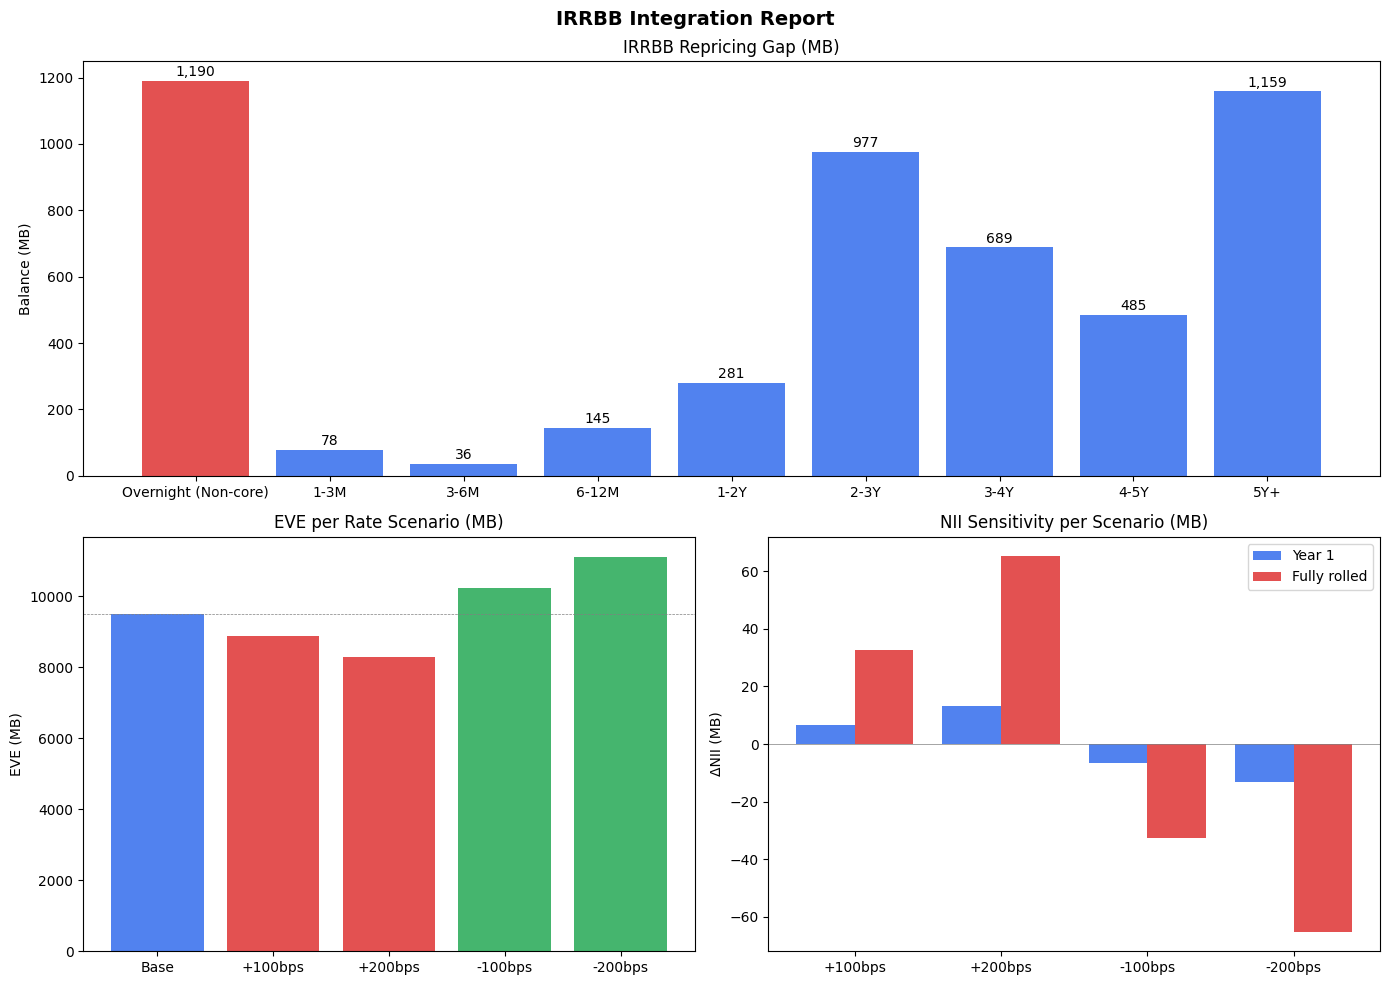

In [15]:
# Plot visualise
plot_irrbb_results(
    report = report,
    nb05 = nb05,
    nb06 = nb06
)